In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
sys.path.append('/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search/')
#print(os.getcwd())
#print(os.listdir("/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Termpaper/termpaper_dynprog/Job Search"))
import Model_components as model
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta
from numba import njit, vectorize


In [2]:
delta = 0.93
gamma = 0.9
eta = 1
k = 300
k1 = 300
k2 = 250
k3 = 200
q1 = 0.3
q2 = 0.3
lmbda = 4.9
N = 6

abar = [0, 1000]

n_a = 50
n_c = 100
T1 = 6
T2 = 18
T3 = 24
T = 44
b1= 222
b2 = 222
b3 = 114 
welfare = 90
w = 675
R = 0.01

htm = 1


In [3]:
params = np.array([delta, gamma, eta, k, lmbda, N])
params_multi = np.array([delta, gamma, eta, k1, k2, k3, q1, q2,lmbda, N])
institutions_pre = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])
b1 = 342
b2 = 171
institutions_post = np.array([ n_a, n_c, T1, T2, T3, T, b1, b2, b3, welfare, w, R])

In [4]:
if htm == 1:
    weights = np.zeros(n_a)
    weights[0] = 1.0
else: 
    a_grid = np.linspace(abar[0], abar[1], n_a)

    # Convert grid to [0,1]
    x = (a_grid - abar[0]) / (abar[1] - abar[0])

    # Bin boundaries halfway between grid points
    edges = np.empty(n_a + 1)
    edges[1:-1] = (x[:-1] + x[1:]) / 2
    edges[0] = 0
    edges[-1] = 1

    alpha = 1.5
    beta_param = 4.0

    # Probability mass in each bin
    weights = np.diff(beta.cdf(edges, alpha, beta_param))

    weights /= weights.sum()

In [5]:
weights

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [6]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(params, institutions_pre, abar)

Optimal consumption of assets solved in 280 iterations, using 0.13433 seconds
Optimal consumption of assets solved in 275 iterations, using 0.12392 seconds


In [7]:
#S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = model.SolveModel(delta, gamma, eta, k, lmbda, N abar, n_a, n_c, T1, T2, T3, T , b1, b2, b3, welfare, w, R)

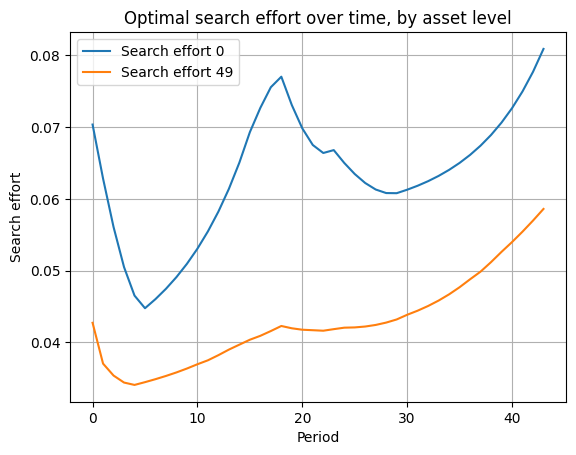

In [8]:
plt.plot(S[0,:-1], label="Search effort 0")
plt.plot(S[49,:-1], label="Search effort 49")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

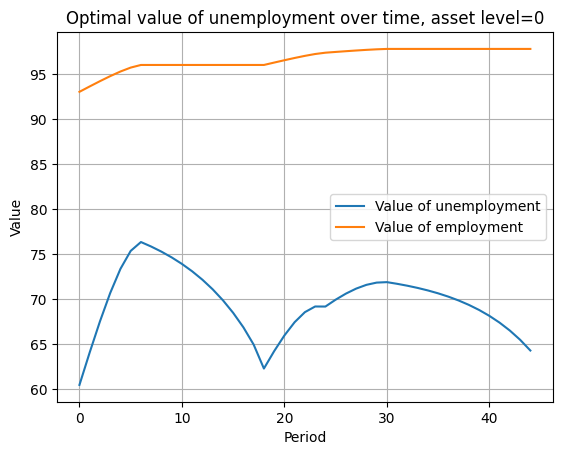

In [9]:
plt.plot(V_unemp[0,:], label="Value of unemployment")
plt.plot(V_emp[0,:], label="Value of employment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of unemployment over time, asset level=0")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
moments = model.simulate_moments(params, institutions_pre, institutions_post, abar, weights)
timevec = np.arange((len(moments))/2)*15 + 15

Optimal consumption of assets solved in 280 iterations, using 0.18185 seconds
Optimal consumption of assets solved in 275 iterations, using 0.13682 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10438 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10088 seconds


In [11]:
# Create target (empirical moments) and covariance matrix
target, cov = model.matchingMoments()

# Create weighting function
W = np.linalg.inv(cov)



In [12]:
# Create SSE, distance measure
SSE = model.sse(params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.11367 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09885 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10098 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09909 seconds


In [13]:
print(f'SSE (Goodness of Fit): {SSE}')

SSE (Goodness of Fit): 3730.7149033836513


In [14]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

pre, post = split_half(moments)


emp_pre, emp_post = split_half(target)


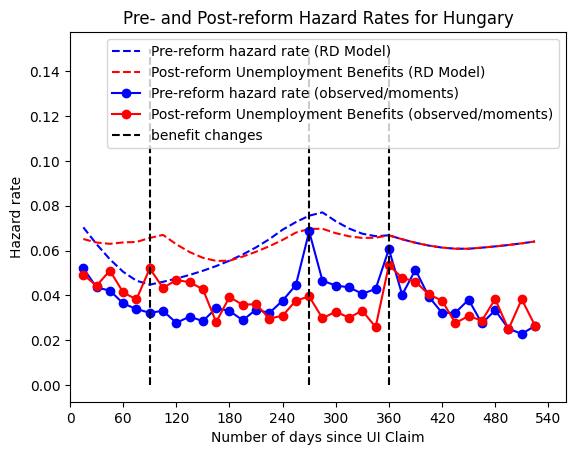

In [15]:
plt.plot(timevec, pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [16]:
fixed_params = params

In [17]:
sse1 = model.sse(fixed_params, target, W, institutions_pre, institutions_post, abar, weights)

Optimal consumption of assets solved in 280 iterations, using 0.10173 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09715 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11298 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10099 seconds


In [18]:
params_full = pd.DataFrame(
    data={"value":[0.93, 0.9, 1, 300, 4.9, 6]},
    index=["delta", "gamma", "eta", "k", "lmbda", "N"]
    )

In [19]:
params_full

,value
delta,0.93
gamma,0.90
eta,1.00
k,300.00
lmbda,4.90
N,6.00


In [20]:
smm_object = model.smm(params_full.copy(), target, W, institutions_pre, institutions_post, abar, weights)

In [21]:
params2 = pd.DataFrame(
    data={"value":[0.3],
    "lower_bound" : [0.01],
    "upper_bound" : [2]},
    index=["gamma"],
    )

In [22]:
params2

,value,lower_bound,upper_bound
gamma,0.3,0.01,2


In [23]:
print(f'GMM SSE for gamma=0.3: {smm_object.sse(params2)}')

Optimal consumption of assets solved in 280 iterations, using 0.10908 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10434 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09901 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09363 seconds
GMM SSE for gamma=0.3: 8743.660581029419


In [24]:
res = om.minimize(criterion=smm_object.sse, params=params2, algorithm='scipy_lbfgsb', )

Optimal consumption of assets solved in 280 iterations, using 0.10444 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 275 iterations, using 0.09952 seconds
Optimal consumption of assets solved in 280 iterations, using 0.12596 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11449 seconds
Optimal consumption of assets solved in 280 iterations, using 0.13509 seconds
Optimal consumption of assets solved in 275 iterations, using 0.15516 seconds
Optimal consumption of assets solved in 280 iterations, using 0.13483 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09892 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10712 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10848 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10477 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10068 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11045 seconds
Optimal consumption of assets solved in 275 iterations, using 0.

In [25]:
print(f'Optimized gamma parameter: {res.params}')
print(f'Objective function(SSE) at optimized gamma (minimum): {res.criterion}')

Optimized gamma parameter:           value  lower_bound  upper_bound
gamma  0.726254         0.01            2
Objective function(SSE) at optimized gamma (minimum): 342.6491432042644


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [26]:
smm_object.params_full.update(res.params)
print(smm_object.params_full)

            value
delta    0.930000
gamma    0.726254
eta      1.000000
k      300.000000
lmbda    4.900000
N        6.000000


In [27]:
params_rd = pd.DataFrame(
    data={"value":params[:5],
    "lower_bound" : [0.01, 1e-2, 0.01, 1e-5, 0.01],
    "upper_bound" : [0.95, 2, 15, 2000, 15]},
    index=["delta", "gamma", "eta", "k", "lmbda"],
    )

In [28]:
params_rd

,value,lower_bound,upper_bound
delta,0.93,0.01000,0.95
gamma,0.90,0.01000,2.00
eta,1.00,0.01000,15.00
k,300.00,0.00001,2000.00
lmbda,4.90,0.01000,15.00


In [29]:
print(f'SMM SSE for params_rd: {smm_object.sse(params_rd)}')


Optimal consumption of assets solved in 280 iterations, using 0.12395 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10565 seconds
Optimal consumption of assets solved in 280 iterations, using 0.1222 seconds
Optimal consumption of assets solved in 275 iterations, using 0.12926 seconds
SMM SSE for params_rd: 3730.7149033836513


In [ ]:
res_rd = om.minimize(criterion=smm_object.criterion, params=params_rd, algorithm='scipy_lbfgsb', )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 280 iterations, using 0.177 seconds
Optimal consumption of assets solved in 275 iterations, using 0.15398 seconds
Optimal consumption of assets solved in 280 iterations, using 0.21196 seconds
Optimal consumption of assets solved in 275 iterations, using 0.2006 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:311: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 280 iterations, using 0.16222 seconds
Optimal consumption of assets solved in 275 iterations, using 0.16494 seconds
Optimal consumption of assets solved in 280 iterations, using 0.12499 seconds
Optimal consumption of assets solved in 275 iterations, using 0.12209 seconds
Optimal consumption of assets solved in 280 iterations, using 0.12403 seconds
Optimal consumption of assets solved in 275 iterations, using 0.12142 seconds
Optimal consumption of assets solved in 280 iterations, using 0.12378 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11678 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11734 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11679 seconds
Optimal consumption of assets solved in 280 iterations, using 0.11564 seconds
Optimal consumption of assets solved in 275 iterations, using 0.11077 seconds
Optimal consumption of assets solved in 280 iterations, using 0.

In [117]:
print(f'Optimized parameters: {res_rd.params}')
print(f'Objective function(SSE) at optimized parameters: {res_rd.criterion}')

Optimized parameters:             value  lower_bound  upper_bound
delta    0.942211      0.01000         0.95
gamma    0.616462      0.01000         2.00
eta      1.345860      0.01000        15.00
k      290.957735      0.00001      2000.00
lmbda    5.878811      0.01000        15.00
Objective function(SSE) at optimized parameters: 276.6127502137423


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [118]:
fig = om.criterion_plot(res_rd)
fig

In [128]:
print(res_rd)

Minimize with 5 free parameters terminated unsuccessfully after 165 criterion evaluations, 165 derivative evaluations and 37 iterations.

The value of criterion improved from 3730.7149033836513 to 276.6127502137423.

The scipy_lbfgsb algorithm reported: ABNORMAL: 

Independent of the convergence criteria used by scipy_lbfgsb, the strength of convergence can be assessed by the following criteria:

                             one_step     five_steps 
relative_criterion_change  2.134e-08*    1.511e-07*  
relative_params_change     2.084e-07*    1.434e-06*  
absolute_criterion_change  5.898e-06*    4.175e-05   
absolute_params_change     2.038e-07*    1.403e-06*  

(***: change <= 1e-10, **: change <= 1e-8, *: change <= 1e-5. Change refers to a change between accepted steps. The first column only considers the last step. The second column considers the last five steps.)


In [143]:
print(res_rd.params)

            value  lower_bound  upper_bound
delta    0.942211      0.01000         0.95
gamma    0.616462      0.01000         2.00
eta      1.345860      0.01000        15.00
k      290.957735      0.00001      2000.00
lmbda    5.878811      0.01000        15.00


In [31]:
res_ls = om.minimize(criterion=smm_object.criterion, params=params_rd, algorithm='scipy_ls_trf', )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 280 iterations, using 0.11335 seconds
Optimal consumption of assets solved in 275 iterations, using 0.10382 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09766 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0958 seconds


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:311: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.warn(msg, FutureWarning)


Optimal consumption of assets solved in 280 iterations, using 0.09684 seconds
Optimal consumption of assets solved in 275 iterations, using 0.1058 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09676 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09502 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10368 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09417 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10512 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09526 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10382 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09792 seconds
Optimal consumption of assets solved in 280 iterations, using 0.10183 seconds
Optimal consumption of assets solved in 275 iterations, using 0.0954 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09

In [ ]:
res_bobyqa = om.minimize(
    fun=smm_object.sse,
    params=params_rd,
    algorithm="nlopt_bobyqa",
)

Optimal consumption of assets solved in 280 iterations, using 0.10558 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09977 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09892 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09345 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0976 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09436 seconds
Optimal consumption of assets solved in 280 iterations, using 0.09732 seconds
Optimal consumption of assets solved in 275 iterations, using 0.09679 seconds
Optimal consumption of assets solved in 359 iterations, using 0.12565 seconds
Optimal consumption of assets solved in 352 iterations, using 0.12029 seconds
Optimal consumption of assets solved in 359 iterations, using 0.12542 seconds
Optimal consumption of assets solved in 352 iterations, using 0.12906 seconds
Optimal consumption of assets solved in 280 iterations, using 0.0

In [ ]:
#insert params_rd on first 5 columns of params
params_opt = params
params_opt[:5] = res_rd.params['value']
params_opt

In [ ]:
#insert params_rd on first 5 columns of params
params_opt2 = params
params_opt2[:5] = res_ls.params['value']
params_opt2

array([8.50423085e-01, 1.35430026e+00, 4.96886849e-01, 1.24618410e+03,
       1.49849727e+01, 6.00000000e+00])

In [ ]:
params_opt3 = params
params_opt3[:5] = res_bobyqa.params['value']
params_opt3

array([  0.92732392,   0.82482039,   1.08844733, 463.10875206,
         7.3887397 ,   6.        ])

In [ ]:
moments = model.simulate_moments(params_opt, institutions_pre, institutions_post, abar, weights)
opt_pre, opt_post = split_half(moments)
moments2 = model.simulate_moments(params_opt2, institutions_pre, institutions_post, abar, weights)
opt2_pre, opt2_post = split_half(moments2)
moments3 = model.simulate_moments(params_opt3, institutions_pre, institutions_post, abar, weights)
opt3_pre, opt3_post = split_half(moments3)

emp_pre, emp_post = split_half(target)


Optimal consumption of assets solved in 269 iterations, using 0.10749 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09405 seconds
Optimal consumption of assets solved in 269 iterations, using 0.14153 seconds
Optimal consumption of assets solved in 264 iterations, using 0.10139 seconds
Optimal consumption of assets solved in 269 iterations, using 0.10011 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09802 seconds
Optimal consumption of assets solved in 269 iterations, using 0.09986 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09494 seconds
Optimal consumption of assets solved in 269 iterations, using 0.10531 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09571 seconds
Optimal consumption of assets solved in 269 iterations, using 0.10216 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09354 seconds


In [ ]:
sse_opt = model.sse(params_opt, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for optimized parameters: {sse_opt}')

sse_opt2 = model.sse(params_opt2, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for second set of optimized parameters: {sse_opt2}')

sse_opt3 = model.sse(params_opt3, target, W, institutions_pre, institutions_post, abar, weights)
print(f'SSE (Goodness of Fit) for third set of optimized parameters: {sse_opt3}')

Optimal consumption of assets solved in 269 iterations, using 0.10083 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09078 seconds
Optimal consumption of assets solved in 269 iterations, using 0.12063 seconds
Optimal consumption of assets solved in 264 iterations, using 0.10232 seconds
SSE (Goodness of Fit) for optimized parameters: 262.76478861425335
Optimal consumption of assets solved in 269 iterations, using 0.0957 seconds
Optimal consumption of assets solved in 264 iterations, using 0.09101 seconds
Optimal consumption of assets solved in 269 iterations, using 0.11145 seconds
Optimal consumption of assets solved in 264 iterations, using 0.12661 seconds
SSE (Goodness of Fit) for second set of optimized parameters: 262.76478861425335


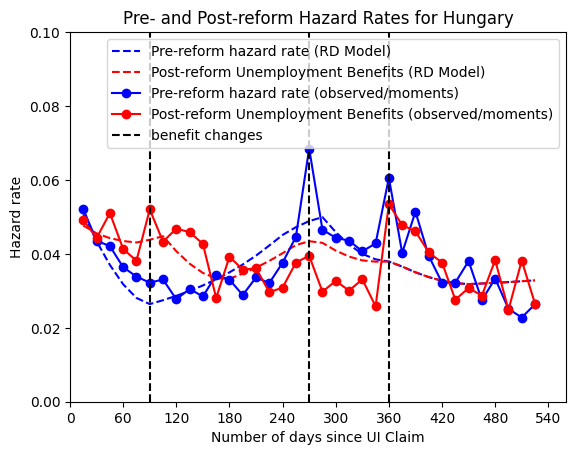

In [39]:
plt.plot(timevec, opt_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, opt_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

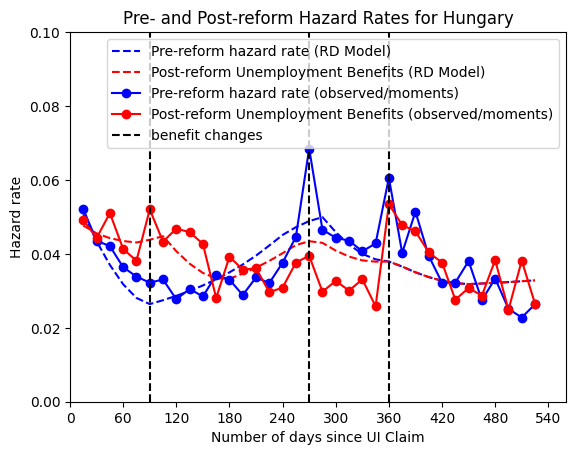

In [40]:
plt.plot(timevec, opt2_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, opt2_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

In [ ]:
plt.plot(timevec, opt3_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='green')
plt.plot(timevec, opt3_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='orange')
plt.plot(timevec, emp_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, emp_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.ylim(0, 0.1) # set x-axis limits to first and last element in timevec
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()